## Introduction

This notebook experiments implementation of a [simple Autoencoder](#simple-autoencoder) for anomaly detection with reconstruction errors, using pytorch. 
Hypothesis: similar to notebook 02, exploring with non-linear AutoEncoder

**Results Summary:** unimproved from the previous attempts. very low f1 score, AUC < 0.5

**Conclusion:** reconstruction of licit transactions is impossible with the Elliptic dataset (basic). The heterogenity in the data is not separatable by the model. 

[**Additional tests:**](#invertability) Since the AUC is consistently low, an inverted calculation was attempted: 
    Standard reconstruction-based anomaly detection assumes anomalies are out-of-distribution. The consistent inversion observed across all methods reveals a secondary property of the Elliptic dataset: illicit transactions exhibit behavioral stereotypy — they are systematically more homogeneous than licit ones, reconstructing with lower error. Under an inverted detection paradigm, validated on a held-out period, this stereotypy becomes the detection signal."

### colab installs

In [1]:
import sys

In [2]:
if 'google.colab' in sys.modules:
    !pip install torch
    !pip install scikit-learn
    !pip install matplotlib as plt, pandas as pd

# Imports

In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline

from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

import torch                                                                              
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# Data loading

In [3]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


There are 166 features to the dataset, 92 local and 74 aggregated. [add source - demistifying... ]
The CSV does not have the columns defined
txid - transaction id
time_step - 1-49 timestamps groups
lf_{number} - local feature number 1-92
af_{number} - aggregated feature number 1-74


In [4]:
cols = ['txId','time_step']


local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols

In [5]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [6]:
# map classes: original licit: 2, original illicit: 1, unknown. 

class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True)


,txId,class
0,230425980,2
1,5530458,2
2,232022460,2
3,232438397,0
4,230460314,2
...,...,...
203764,173077460,2
203765,158577750,2
203766,158375402,1
203767,158654197,2


In [7]:
df = pd.merge(features, classes, on='txId')

## Graph Feature Enrichment

In [8]:
# feature enrichment - add edges
def add_graph_features(target_df, input_edges):                                           
      node_ids = set(target_df['txId'])                                                   

        # select only edgest in in- and out- ids                                                                                   
      relevant_edges = input_edges[                                                         
          input_edges['txId1'].isin(node_ids) &                                             
          input_edges['txId2'].isin(node_ids)                                               
      ]                                                                                     
                                                                                            
      G = nx.from_pandas_edgelist(relevant_edges, 'txId1', 'txId2',                         
                                   create_using=nx.DiGraph())                               
                                                                                            
      # directed degree                                                                     
      in_degree  = dict(G.in_degree())      # directed degree in                                                
      out_degree = dict(G.out_degree())                      # out                            
      clustering = nx.clustering(G.to_undirected())    # clustering coefficient                                       
      pagerank = nx.pagerank(G, alpha=0.85)   

      idx = target_df['txId']
      new_cols_df = target_df.assign(
            in_degree = idx.map(lambda x: in_degree.get(x, 0)),
            out_degree= idx.map(lambda x: out_degree.get(x, 0)),
            degree_ratio=  idx.map(lambda x: in_degree.get(x, 0) / (out_degree.get(x, 0) + 1e-9)),
            clustering_coef= idx.map(lambda x: clustering.get(x, 0)),
            pagerank= idx.map(lambda x: pagerank.get(x, 0)),
            )

                                                                                          
      return new_cols_df
#pd.concat([target_df, new_cols_df], axis=1) 


In [9]:
enriched_df = add_graph_features(df, edges)

/tmp/ipykernel_96773/1227313737.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_cols_df = target_df.assign(


In [10]:
enriched_df.shape

(203769, 173)

In [11]:
train_df = df[(df['class'] == 0) & (df['time_step'] <= 35)].copy()
val_df = df[df['time_step'].between(36,40)].copy()
test_df = df[df['time_step'] > 40].copy()


train on licit class 0
training set: time-step 1-30
val: 31-49

In [14]:
# Identify feature columns (excluding metadata)
metadata_cols = ['txId', 'time_step', 'class']


X_train_raw = train_df.drop(columns=metadata_cols)
X_val_raw = val_df.drop(columns=metadata_cols)
X_test_raw = test_df.drop(columns=metadata_cols)


# Simple Autoencoder

justification : 
  it tests whether non-linearity alone (same reconstruction principle as NMF/TSVD) is       
  sufficient to separate fraud from licit

* metrics for reconstruction error: https://www.shadecoder.com/de/topics/reconstruction-error-a-comprehensive-guide-for-2025

## pipeline definition

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
class Autoencoder(nn.Module):
    """ an autoencoder model with 2 layers"""
    def __init__(self, input_dim, hidden_dim=128, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
            # no output activation — StandardScaled data can be negative
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [17]:
def scaler_pipeline(X_train, X_val,X_test, feature_cols, graph_cols=None):
    scaler_features = StandardScaler()

    if graph_cols:                                                             
        scaler_graph    = RobustScaler()
        X_train_scaled = np.hstack([
            scaler_features.fit_transform(X_train[feature_cols]),                                
            scaler_graph.fit_transform(X_train[graph_cols])                                      
        ])
        X_val_scaled = np.hstack([
            scaler_features.transform(X_val[feature_cols]),
            scaler_graph.transform(X_val[graph_cols])
        ])
        X_test_scaled = np.hstack([                                                               
            scaler_features.transform(X_test[feature_cols]),
            scaler_graph.transform(X_test[graph_cols])
        ])   
        scalers = {'features': scaler_features, 'graph': scaler_graph}
    else: 
        X_train_scaled = scaler_features.fit_transform(X_train[feature_cols])                                
        X_val_scaled = scaler_features.transform(X_val[feature_cols])                                                                                     
        X_test_scaled = scaler_features.transform(X_test[feature_cols])                                                                                     
        scalers = {'features': scaler_features}
    return X_train_scaled, X_val_scaled, X_test_scaled, scalers

In [28]:
def train_autoencoder(X_train,X_val, hidden_dim=64, latent_dim=16, epochs=50, batch_size=256, lr=1e-3, patience=5):
    model = Autoencoder(X_train.shape[1], hidden_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train)), batch_size=batch_size, shuffle=True)
    
    best_val_loss = float('inf')
    best_weights  = None
    no_improve    = 0
    losses        = []

    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(batch)
        losses.append(epoch_loss / len(X_train))

        model.eval()
        with torch.no_grad():
            X_val_t  = torch.FloatTensor(X_val).to(device)
            val_loss = criterion(model(X_val_t), X_val_t).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch + 1} (best val loss: {best_val_loss:.6f})')
            break
    if best_weights is not None:
        model.load_state_dict(best_weights)

    return model, losses


def score_autoencoder(model, X_val):
    model.eval()
    with torch.no_grad():
        X_v = torch.FloatTensor(X_val)
        errors = torch.mean((X_v - model(X_v)) ** 2, dim=1).numpy()
    return errors
  

def ae_orchestrator(X_train, X_val, X_test, val_df, test_df, feature_cols, learned_class=0, graph_cols=None,
                      hidden_dim=64, latent_dim=16, epochs=50, batch_size=256,
                      lr=1e-3,  patience=5):
  
    X_train_scaled, X_val_scaled, X_test_scaled, scalers = scaler_pipeline(X_train=X_train, X_val=X_val, X_test=X_test, feature_cols=feature_cols, graph_cols=graph_cols)

    # scale x_val: 
    licit_mask         = (val_df['class'] == learned_class).values
    X_val_licit_scaled = X_val_scaled[licit_mask]  
   
    if graph_cols and 'graph' in scalers:
        X_val_scaled = np.hstack([
            X_val_scaled,
            scalers['graph'].transform(licit_mask[graph_cols])
        ]) 
    model, losses = train_autoencoder(X_train_scaled, X_val_licit_scaled, hidden_dim, latent_dim,
                                        epochs, batch_size, patience=patience, lr=lr)
    
    # val AUC:
    labeled_mask = val_df[val_df['class'] < 2].copy()
    X_val_labeled_scaled = scalers['features'].transform(labeled_mask[feature_cols])
    if graph_cols and 'graph' in scalers:
        X_val_labeled_scaled = np.hstack([
            X_val_labeled_scaled,
            scalers['graph'].transform(labeled_mask[graph_cols])
        ])
    val_errors = score_autoencoder(model, X_val_labeled_scaled)
    val_auc = roc_auc_score(labeled_mask['class'].astype(int), val_errors)
    print(f'Val — ROC-AUC: {val_auc:.4f}')

    
    errors = score_autoencoder(model, X_test_scaled)

    test_results = pd.DataFrame({
        'txId':          test_df['txId'].values,
        'time_step':     test_df['time_step'].values,
        'class':         test_df['class'].values,
        'anomaly_score': errors
    })
    labeled = test_results[test_results['class'] < 2]
    auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])
    ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
    print(f'ROC-AUC: {auc:.4f} | AP: {ap:.4f}')
    print(labeled.groupby('class')['anomaly_score'].describe())
    return model, losses, test_results, auc, ap

    


In [48]:
def plot_ae_latent_comparison(metrics_df, latent_dims, results, title_model):

    fig, axes = plt.subplots(1 + len(latent_dims), 1, figsize=(10, 4 * (1 + len(latent_dims))))

    # top: AUC and AP across latent dims
    ax = axes[0]
    x = range(len(latent_dims))
    ax.plot(x, metrics_df['auc'], marker='o', label='ROC-AUC', color='steelblue')
    ax.plot(x, metrics_df['ap'],  marker='o', label='AP',       color='crimson')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='random')
    ax.set_xticks(x)
    ax.set_xticklabels([f'ld={d}' for d in latent_dims])
    ax.set_ylabel('Score')
    ax.set_title(f'\nAUC / AP by latent dimension')
    ax.legend()

    # one boxplot per latent_dim — anomaly score distribution by class
    for i, ld in enumerate(latent_dims):
        ax = axes[i + 1]
        labeled = results[ld]['test_results'][results[ld]['test_results']['class'] < 2]
        labeled.boxplot(column='anomaly_score', by='class', ax=ax)
        ax.set_title(f'{title_model}: Anomaly Score Distribution by Class\n\nlatent_dim={ld}  |  AUC={metrics_df.loc[i,"auc"]:.3f} | AP={metrics_df.loc[i,"ap"]:.3f}\n')
        ax.set_xlabel('Class (0=licit, 1=illicit)')
        ax.set_ylabel('Reconstruction error')

    
    plt.tight_layout()
    plt.show()

    return results, metrics_df

## Training and eval

In [20]:
feature_cols = local_cols + agg_cols   # lf_* and af_* only   
                                                                                            
model, losses, test_results, auc, ap = ae_orchestrator(
    X_train=train_df[feature_cols],                                                               
    X_val=val_df[feature_cols],
    val_df=val_df,
    X_test=test_df[feature_cols],
    test_df=test_df,
    feature_cols=feature_cols,
    hidden_dim=64, latent_dim=16, epochs=50
    ) 

Val — ROC-AUC: 0.2345
ROC-AUC: 0.2859 | AP: 0.0337
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.349290  1.578245  0.013081  0.091746  0.152826  0.271349   
1       524.0  0.161852  1.128827  0.009703  0.052501  0.087037  0.143318   

             max  
class             
0      97.278069  
1      25.858135  


In [41]:
ld = [9, 30, 70, 100, 160]

results = {}
metrics = []
for dim in ld:
    print(f'dimensions: {dim}')
    model, losses, test_results, auc, ap = ae_orchestrator(
    X_train=train_df[feature_cols],
    X_val=val_df[feature_cols],
    X_test=test_df[feature_cols],
    val_df =val_df,
    test_df =test_df,
    feature_cols=feature_cols,
    hidden_dim=64, latent_dim=dim, epochs=50
    ) 

    results[dim] = {'test_results': test_results, 'losses': losses}
    metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

metrics_df = pd.DataFrame(metrics)



dimensions: 9
Early stopping at epoch 46 (best val loss: 0.386793)
Val — ROC-AUC: 0.2433
ROC-AUC: 0.2929 | AP: 0.0344
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.456990  1.668289  0.024936  0.135913  0.221493  0.384327   
1       524.0  0.246933  1.799443  0.024877  0.083956  0.125986  0.207536   

             max  
class             
0      89.474068  
1      41.242329  
dimensions: 30
Early stopping at epoch 36 (best val loss: 0.333103)
Val — ROC-AUC: 0.2162
ROC-AUC: 0.2537 | AP: 0.0324
        count      mean       std       min       25%       50%       75%  \
class                                                                       
0      9449.0  0.405700  2.061586  0.016514  0.110930  0.179715  0.301379   
1       524.0  0.197896  1.729359  0.008939  0.054609  0.087764  0.154458   

             max  
class             
0      86.518700  
1      39.63

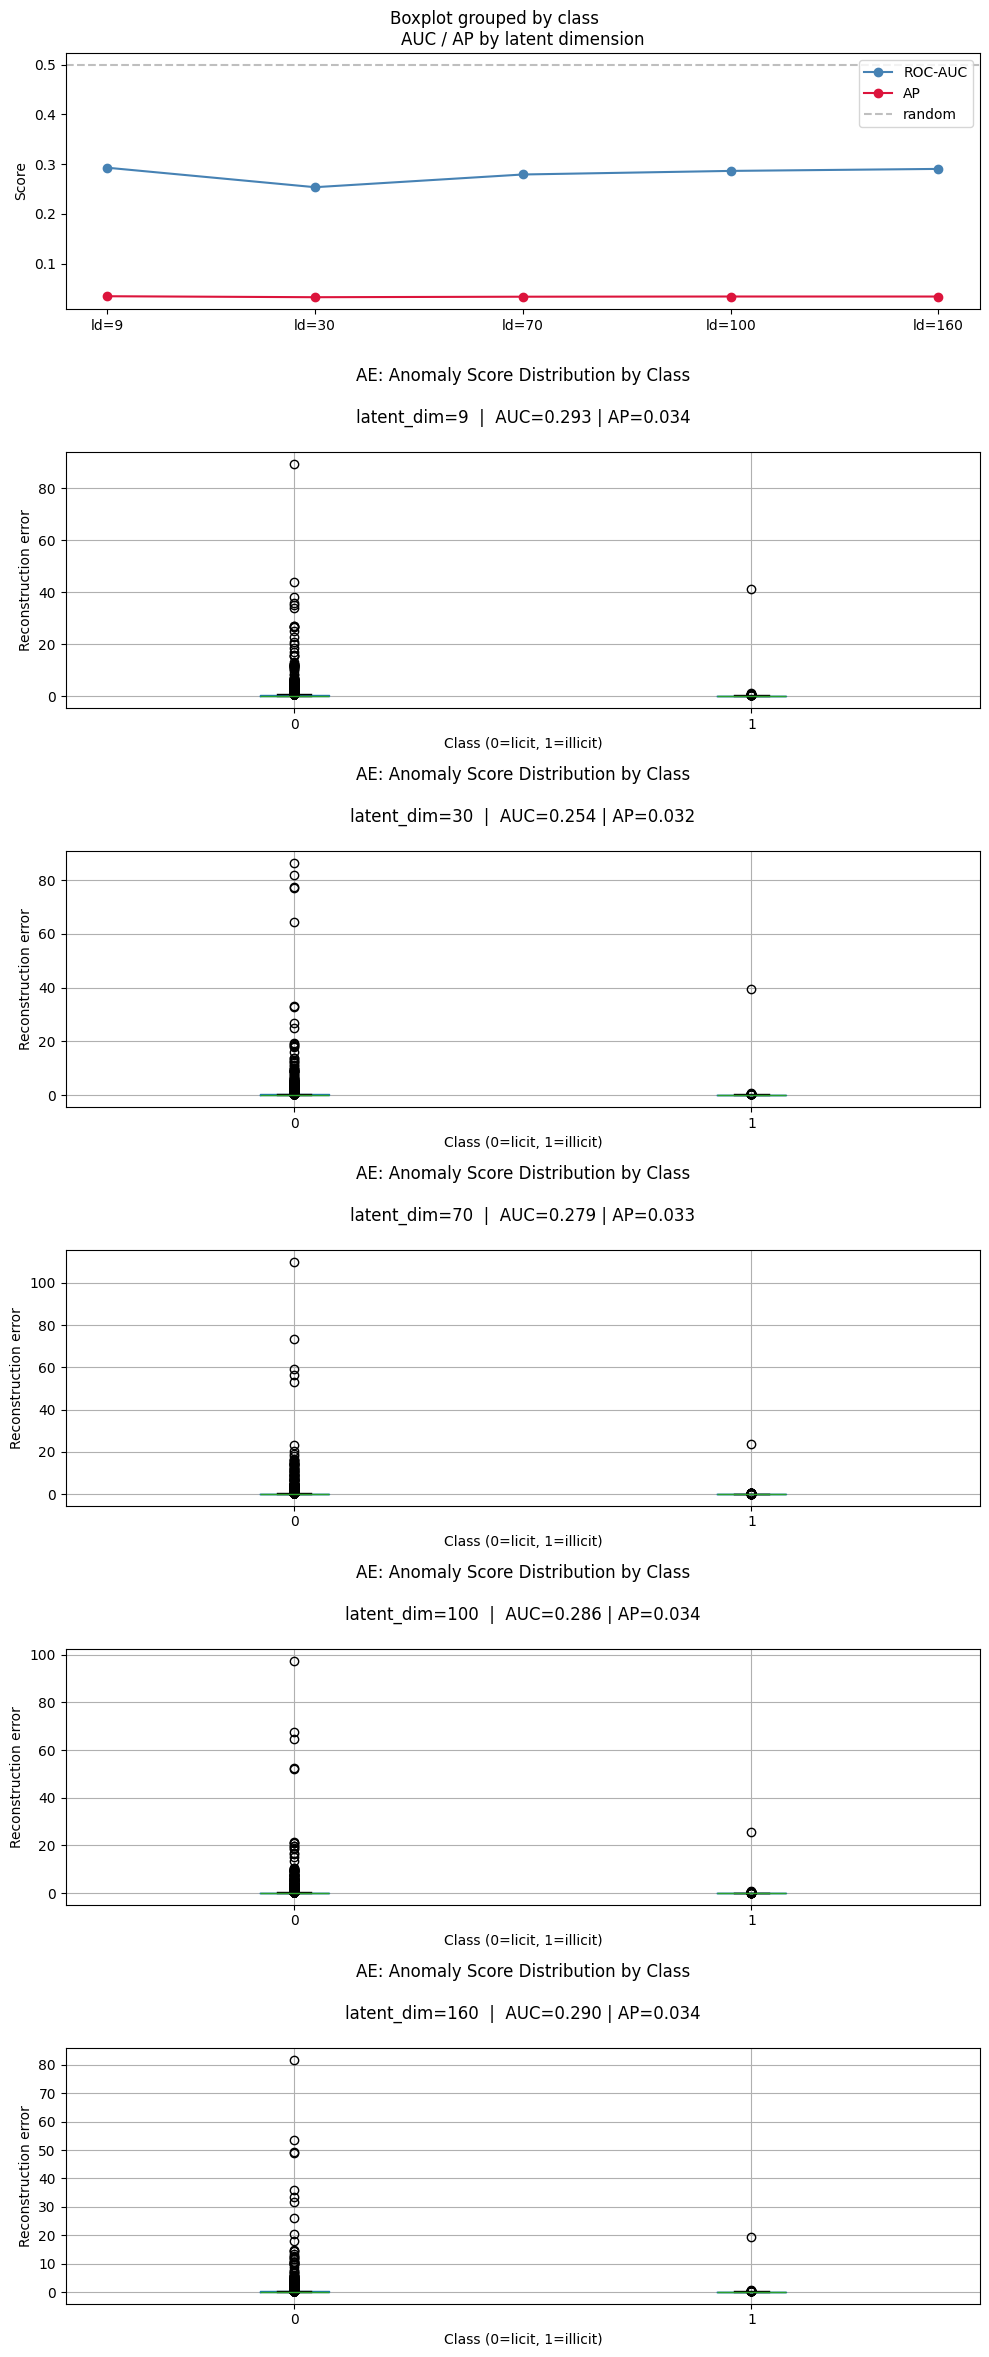

({9: {'test_results':             txId  time_step class  anomaly_score
   0       12781680         41     0       2.953881
   1       39010634         41     2       0.176110
   2       12688678         41     0       0.204529
   3       12688662         41     2       0.135104
   4       12803377         41     2       0.104733
   ...          ...        ...   ...            ...
   42161  173077460         49     2       0.102362
   42162  158577750         49     2       0.148720
   42163  158375402         49     1       0.291516
   42164  158654197         49     2       0.112709
   42165  157597225         49     2       0.155786
   
   [42166 rows x 4 columns],
   'losses': [0.8512946844645346,
    0.6197267654089785,
    0.5229222409167661,
    0.46888319300022163,
    0.4295323918758905,
    0.38763208964525053,
    0.36327407997017697,
    0.34388615805208134,
    0.3290895263907019,
    0.3486865390544311,
    0.31578133956123366,
    0.30865081350289486,
    0.28765730574569

In [49]:
plot_ae_latent_comparison(metrics_df, ld, results, title_model="AE")

conclusion: also in advanced architecture - 4 layers, higher ld and large layer size, the reconstruction error for class 0 remains with mean larger than that for class 1. 

# Graph Feature Enrichment AE

In [23]:
enriched_df = add_graph_features(df, edges)
e_train_df = enriched_df[(enriched_df['class'] == 0) & (enriched_df['time_step'] <= 40)].copy()
e_test_df = enriched_df[enriched_df['time_step'] > 40].copy()

graph_cols = ['in_degree', 'out_degree', 'degree_ratio', 'clustering_coef', 'pagerank'] 
# graph_scaler = RobustScaler() 
# e_train_df[graph_cols] = graph_scaler.fit_transform(e_train_df[graph_cols])                   
# e_test_df[graph_cols]  = graph_scaler.transform(e_test_df[graph_cols]) 

enriched_cols = feature_cols + graph_cols


/tmp/ipykernel_612193/1227313737.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_cols_df = target_df.assign(


In [ ]:
ld = [30, 70, 100, 160]

results = {}
metrics = []
for dim in ld:
    print(f'dimensions: {dim}')

    model, losses, test_results, auc, ap = ae_orchestrator(
        e_train_df[enriched_cols],                                                               
        e_test_df[enriched_cols],
        e_test_df,
        feature_cols=feature_cols,
        graph_cols=graph_cols,
        hidden_dim=64, latent_dim=16, epochs=50
        ) 
    
    results[dim] = {'test_results': test_results, 'losses': losses}
    metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

metrics_df = pd.DataFrame(metrics)



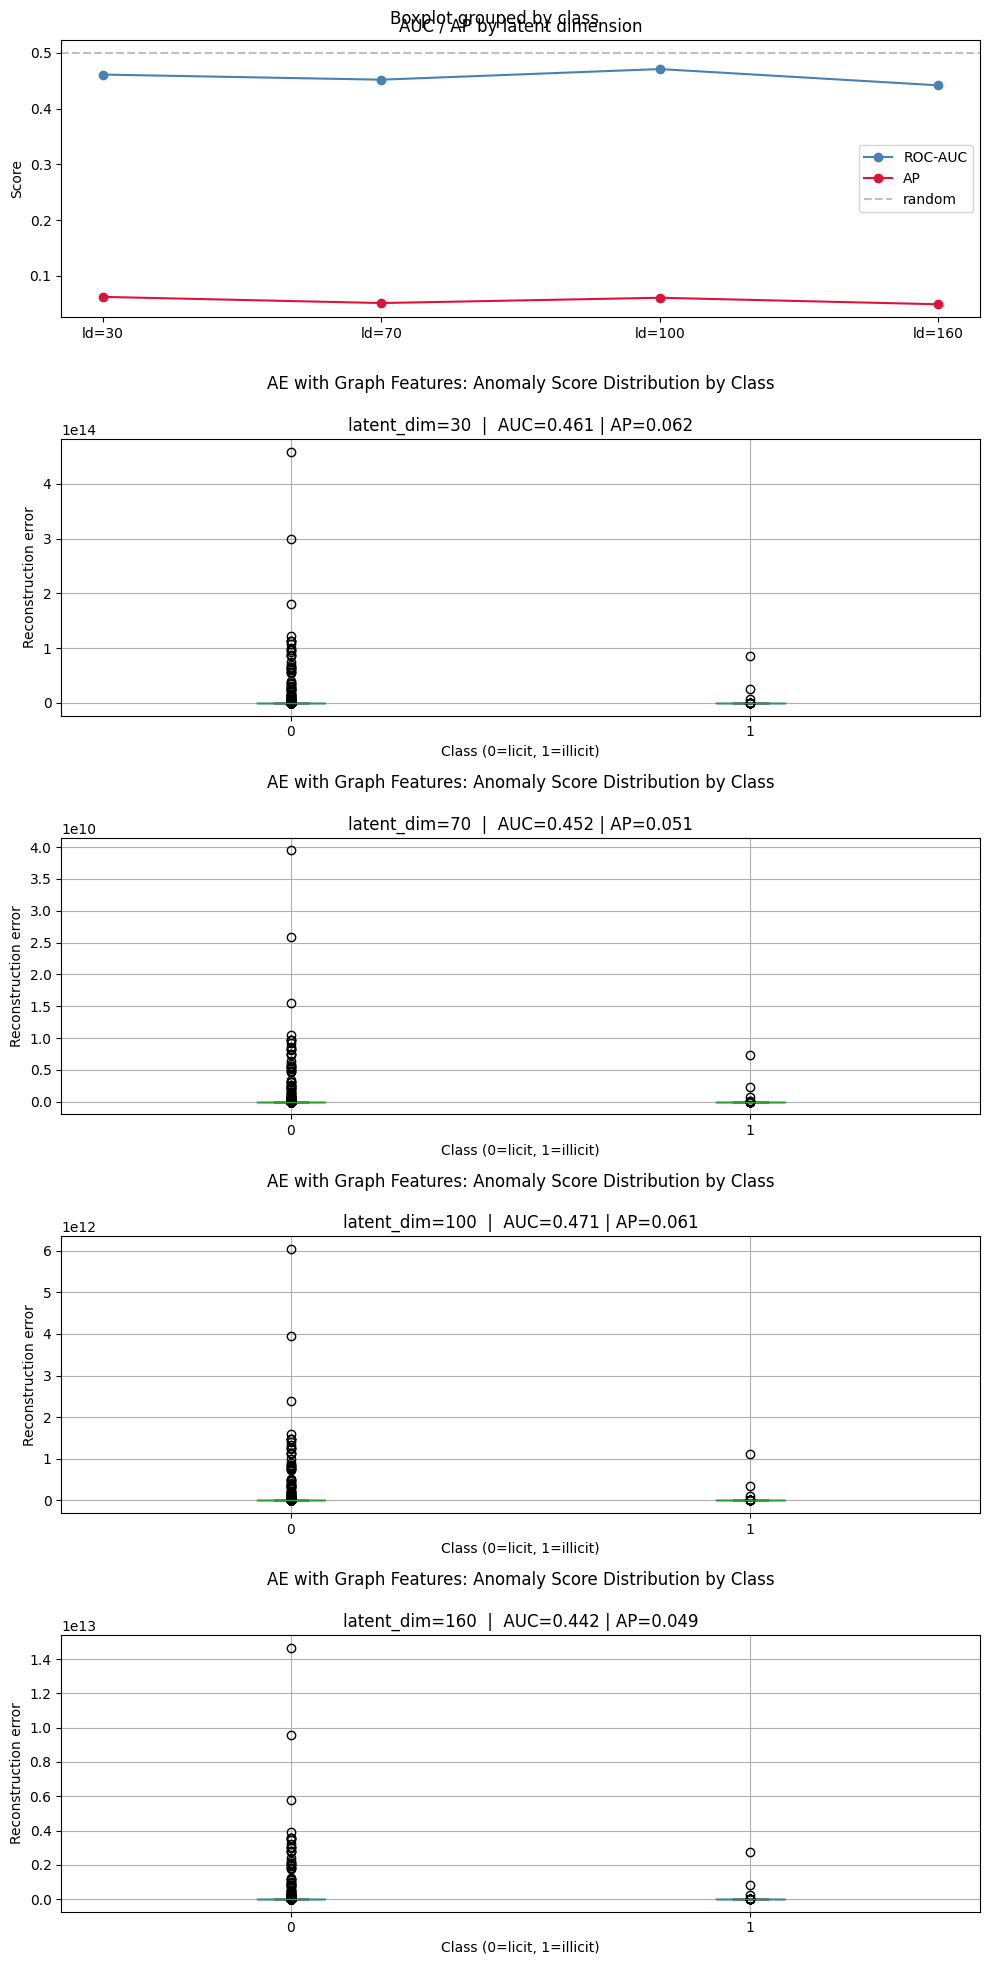

({30: {'test_results':             txId  time_step class  anomaly_score
   0       12781680         41     0   1.042186e+01
   1       39010634         41     2   1.298763e+10
   2       12688678         41     0   5.489766e-01
   3       12688662         41     2   2.350480e-01
   4       12803377         41     2   2.150450e-01
   ...          ...        ...   ...            ...
   42161  173077460         49     2   1.298782e+10
   42162  158577750         49     2   1.298770e+10
   42163  158375402         49     1   4.160370e-01
   42164  158654197         49     2   1.298769e+10
   42165  157597225         49     2   1.298756e+10
   
   [42166 rows x 4 columns],
   'losses': [19135606720321.223,
    66460077180.15941,
    1864437523.3262513,
    2956082240.03537,
    1800801187871.1099,
    239872514939.26044,
    20383723260.117165,
    203566948.18974516,
    754988214949.9304,
    3125274539616.615,
    11251070394.078478,
    7368932297.718883,
    524035149.202817,
    17783

In [44]:
plot_ae_latent_comparison(metrics_df, ld, results, title_model= "AE with Graph Features")#, title="AE AUC and Average Precision, per Latent Dimension")

## Temporal Autoencoder

Rationale - 
  The static AE trains once on all licit transactions (t≤40) and scores the remainder.
  This assumes licit behavior is stationary — the same patterns persist across  all timesteps. As with the linear CF models, The temporal AE tests whether **adapting the model to evolving licit behavior** improves anomaly detection. At each timestep t, a new model is trained on all licit transactions seen so far (t' < t) and used to score only transactions at t.

**Architecture**
  Same 2-layer symmetric architecture as the static AE baseline, to isolate the effect
  of the temporal approach from architectural complexity:
  input → hidden → latent → hidden → input

  **Conditional conclusion**
  - If AUC improves significantly over static AE → temporal adaptation adds signal;
    concept drift in licit behavior is a meaningful factor
  - If AUC remains ≤ 0.5 → neither non-linearity nor temporal adaptation is sufficient;
    the reconstruction error paradigm is fundamentally limited on this dataset
    regardless of model complexity or training strategy


In [25]:
class Autoencoder2L(nn.Module):
      """2-layer symmetric autoencoder — baseline architecture for temporal experiment"""
      def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
          super().__init__()
          self.encoder = nn.Sequential(
              nn.Linear(input_dim, hidden_dim), nn.ReLU(),
              nn.Linear(hidden_dim, latent_dim), nn.ReLU()
          )
          self.decoder = nn.Sequential(
              nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
              nn.Linear(hidden_dim, input_dim)
          )
      def forward(self, x):
          return self.decoder(self.encoder(x))


def train_autoencoder_2l(X_train, hidden_dim=64, latent_dim=16,
                        epochs=30, batch_size=256, lr=1e-3):
    model = Autoencoder2L(X_train.shape[1], hidden_dim, latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_train)),
                        batch_size=batch_size, shuffle=True)
    model.train()
    for _ in range(epochs):
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()
    return model


In [26]:
def temporal_autoencoder(df, feature_cols,
                            latent_dim=16, hidden_dim=64,
                            epochs=30, batch_size=256, lr=1e-3):
      all_results = []
      min_train   = latent_dim * 10   # guard: need enough samples to fit rank components

      for t in sorted(df['time_step'].unique()):
          train = df[(df['class'] == 0) & (df['time_step'] < t)]
          test  = df[df['time_step'] == t]

          if len(train) < min_train:
              continue

          X_train = np.array(train[feature_cols])
          X_test  = np.array(test[feature_cols])

          scaler    = StandardScaler()
          X_train_s = scaler.fit_transform(X_train)
          X_test_s  = scaler.transform(X_test)

          model  = train_autoencoder_2l(X_train_s, hidden_dim=hidden_dim,
                                         latent_dim=latent_dim,
                                         epochs=epochs, batch_size=batch_size, lr=lr)
          errors = score_autoencoder(model, X_test_s)

          all_results.append(pd.DataFrame({
              'txId':          test['txId'].values,
              'time_step':     t,
              'class':         test['class'].values,
              'anomaly_score': errors
          }))

      return pd.concat(all_results, ignore_index=True)


In [40]:
def plot_temporal_errors(all_results, title):
    labeled = all_results[all_results['class'] < 2]

    # mean + std per class per timestep
    stats = labeled.groupby(['time_step', 'class'])['anomaly_score'].agg(['mean', 'std']).reset_index()
  
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
                
    colors = {0: 'steelblue', 1: 'crimson'}
    labels = {0: 'Licit', 1: 'Illicit'}

    # top: mean error per class with std band
    for cls in [0, 1]:
        d = stats[stats['class'] == cls]
        ax1.plot(d['time_step'], d['mean'], color=colors[cls], label=labels[cls])
        ax1.fill_between(d['time_step'],
                        d['mean'] - d['std'],
                        d['mean'] + d['std'],
                        alpha=0.2, color=colors[cls])
    ax1.set_ylabel('Mean reconstruction error')
    ax1.legend()
    #ax1.axvline(x=35, color='gray', linestyle='--', alpha=0.5, label='train cutoff')

    # bottom: gap (illicit - licit) — positive = model detects fraud
    licit   = stats[stats['class'] == 0].set_index('time_step')['mean']
    illicit = stats[stats['class'] == 1].set_index('time_step')['mean']
    gap = illicit - licit
    ax2.bar(gap.index, gap.values, color=gap.apply(lambda x: 'crimson' if x > 0 else 'steelblue'))
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Error gap (illicit − licit)')
    ax2.set_xlabel('Time step')
    plt.suptitle(title)

    plt.tight_layout()
    plt.show()


In [41]:
temporal_results = temporal_autoencoder(
      enriched_df, enriched_cols,                   
      latent_dim=100, hidden_dim=64, epochs=30
  )                                                                                         
   

Temporal AE — ROC-AUC: 0.2904 | AP: 0.0670
         count      mean        std       min       25%       50%       75%  \
class                                                                         
0      39889.0  0.469282  15.097620  0.003322  0.037092  0.072323  0.154607   
1       4528.0  0.183401   2.144116  0.002838  0.020145  0.036080  0.060894   

               max  
class               
0      1902.450195  
1        83.292572  


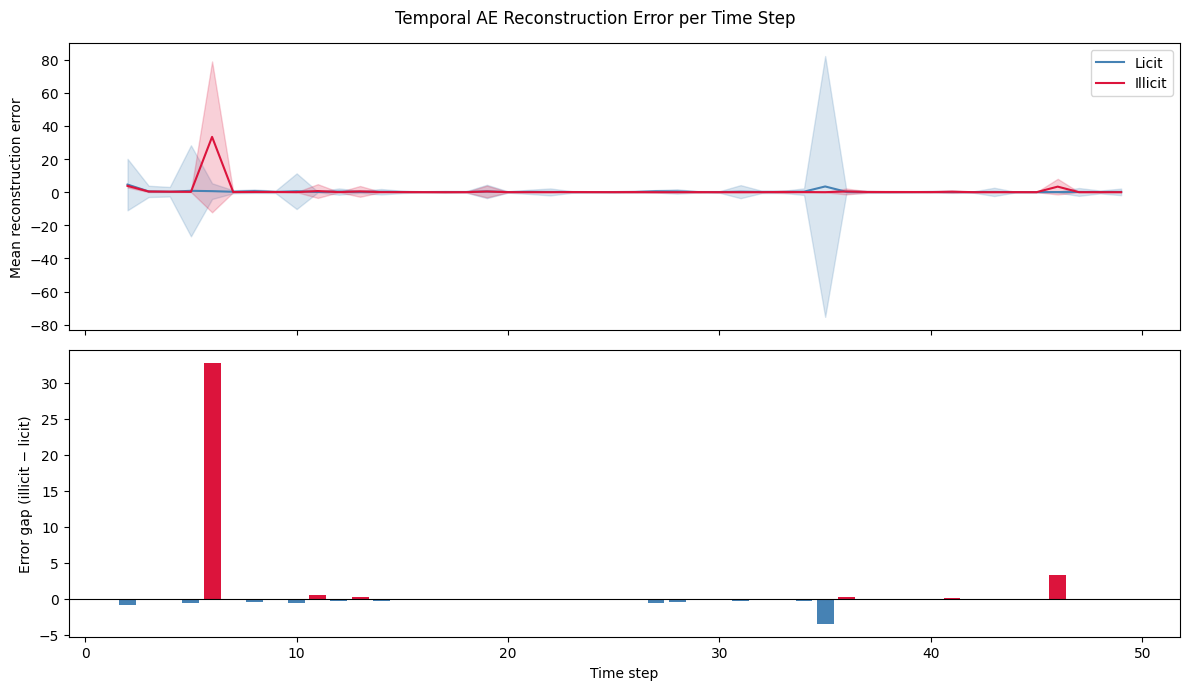

In [42]:
labeled = temporal_results[temporal_results['class'] < 2]                                 
auc = roc_auc_score(labeled['class'].astype(int), labeled['anomaly_score'])                           
ap  = average_precision_score(labeled['class'].astype(int), labeled['anomaly_score'])
print(f'Temporal AE — ROC-AUC: {auc:.4f} | AP: {ap:.4f}')                                 
print(labeled.groupby('class')['anomaly_score'].describe())
                                                                                        
# reuse temporal error plot from NMF experiment                                           
plot_temporal_errors(temporal_results, title='Temporal AE Reconstruction Error per Time Step') 

# Invertability

"Standard reconstruction-based anomaly detection assumes anomalies are out-of-distribution. The consistent inversion observed across all methods reveals a secondary property of the Elliptic dataset: illicit transactions exhibit behavioral stereotypy — they are systematically more homogeneous than licit ones, reconstructing with lower error. Under an inverted detection paradigm, validated on a held-out period, this stereotypy becomes the detection signal."


In [81]:
def ae_inverted_orchestrator(df, feature_cols,                                            
                            train_ts=range(1,31),                                       
                            val_ts=range(31,41),                                        
                            test_ts=range(41,50),                                       
                            hidden_dim=64, latent_dim=16,                               
                            epochs=50, batch_size=256, lr=1e-3):                        

    train_df = df[(df['time_step'].isin(train_ts)) & (df['class'] == 0)]                  
    val_df   = df[df['time_step'].isin(val_ts)]
    test_df  = df[df['time_step'].isin(test_ts)]                                          
                
    X_train = np.array(train_df[feature_cols])                                            
    scaler  = StandardScaler().fit(X_train)
                                                                                        
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(np.array(val_df[feature_cols]))
    X_test_s  = scaler.transform(np.array(test_df[feature_cols]))                         

    model = train_autoencoder_2l(X_train_s, hidden_dim=hidden_dim,                        
                                latent_dim=latent_dim, epochs=epochs,
                                batch_size=batch_size, lr=lr) 
    # validation: confirm inversion direction                                             
    val_errors  = score_autoencoder(model, X_val_s)
    val_labeled = val_df[val_df['class'] < 2].copy()                                      
    val_labeled['anomaly_score'] = val_errors[val_df['class'] < 2]                        

    # generate inverted auc                                                                                
    auc_standard = roc_auc_score(val_labeled['class'].astype(int),  val_labeled['anomaly_score'])     
    auc_inverted = roc_auc_score(val_labeled['class'].astype(int), -val_labeled['anomaly_score'])

    
    direction = -1 if auc_inverted > auc_standard else 1                                  
    print(f'Validation — standard AUC: {auc_standard:.3f} | '
        f'inverted AUC: {auc_inverted:.3f} | using: {"inverted" if direction==-1 else "standard"}')                                                                             
                                                                                            
    # test with validated direction                                                       
    test_errors  = score_autoencoder(model, X_test_s)
    test_labeled = test_df[test_df['class'] < 2].copy()                                   
    test_labeled['anomaly_score'] = direction * test_errors[test_df['class'] < 2]
                                                                                        
    auc = roc_auc_score(test_labeled['class'].astype(int), test_labeled['anomaly_score'])             
    ap  = average_precision_score(test_labeled['class'].astype(int), test_labeled['anomaly_score'])   
    print(f'Test     — ROC-AUC: {auc:.4f} | AP: {ap:.4f}')                                
    print(test_labeled.groupby('class')['anomaly_score'].describe())                      
                                                                                        
    return model, test_labeled, auc, ap 

dimensions: 30
Validation — standard AUC: 0.253 | inverted AUC: 0.747 | using: inverted
Test     — ROC-AUC: 0.6885 | AP: 0.1559
        count      mean       std         min       25%       50%       75%  \
class                                                                         
0      9449.0 -0.892867  5.156142 -349.605164 -0.477435 -0.230193 -0.130978   
1       524.0 -0.617449  7.081252 -161.479919 -0.191496 -0.137440 -0.095926   

            max  
class            
0     -0.027202  
1     -0.023658  
dimensions: 100
Validation — standard AUC: 0.206 | inverted AUC: 0.794 | using: inverted
Test     — ROC-AUC: 0.7332 | AP: 0.2112
        count      mean       std         min       25%       50%       75%  \
class                                                                         
0      9449.0 -0.870903  4.755116 -330.332916 -0.493043 -0.259445 -0.154865   
1       524.0 -0.594332  6.695517 -152.674164 -0.216281 -0.131202 -0.093520   

            max  
class            
0

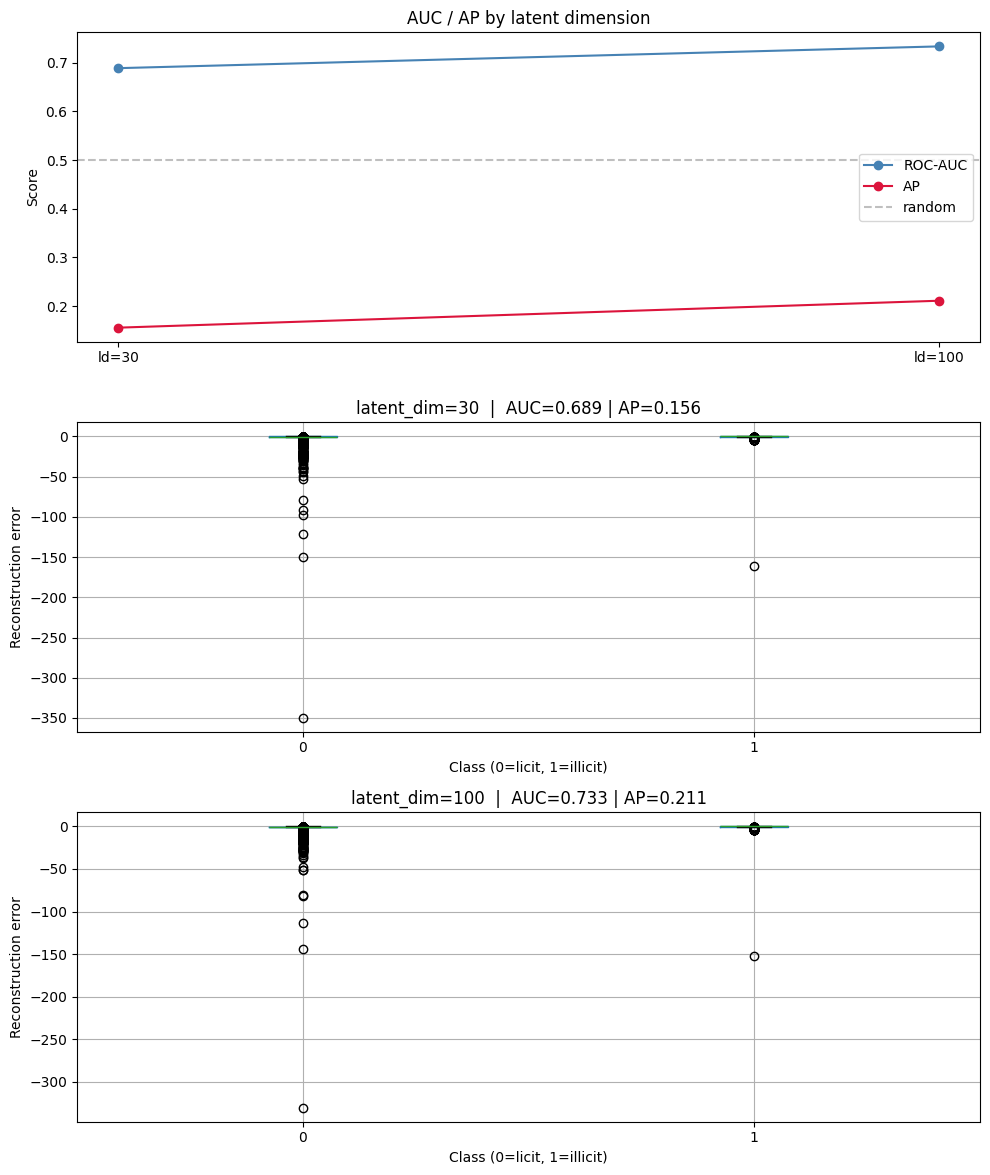

({30: {'test_results':              txId  time_step      lf_1      lf_2      lf_3      lf_4  \
   161603   12781680         41  2.740423  2.523310  2.128587 -0.046932   
   161605   12688678         41 -0.172918  0.016050  1.018602 -0.121970   
   161608   12805689         41  0.081972  6.441913  2.128587  3.855018   
   161609   13284351         41 -0.170928  0.335420  1.573595  0.103143   
   161610   13425520         41 -0.172689  0.456181  1.573595  0.178180   
   ...           ...        ...       ...       ...       ...       ...   
   203752   80329479         49 -0.159293 -0.037276  1.018602 -0.121970   
   203754  158406298         49 -0.172962 -0.126566  1.018602 -0.121970   
   203759  158375075         49 -0.170412 -0.078164  1.018602  0.028105   
   203763  147478192         49 -0.093732 -0.116160  1.018602 -0.121970   
   203766  158375402         49 -0.172014 -0.078182  1.018602  0.028105   
   
               lf_5      lf_6      lf_7      lf_8  ...     af_65     af_66  

In [83]:
ld = [30,  100]

results = {}
metrics = []
for dim in ld:
    print(f'dimensions: {dim}')

    model, test_results, auc, ap = ae_inverted_orchestrator(
        df, feature_cols=feature_cols,       
        ) 
    
    results[dim] = {'test_results': test_results, 'losses': losses}
    metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

metrics_df = pd.DataFrame(metrics)

plot_ae_latent_comparison(metrics_df, ld, results)

The inverted paradigm achieves ROC-AUC ~0.7, confirming that behavioral stereotypy is a
   real and systematic property of a subset of illicit transactions. However, the low AP and
   high variance indicate that this signal is partial — only fraud exhibiting regular,
  predictable patterns is detectable. Illicit transactions that are behaviorally diverse
  remain indistinguishable from licit ones under reconstruction-based methods. This suggests
   the Elliptic dataset contains heterogeneous fraud subtypes with different detectability
  profiles."

  Practical implication: AUC 0.7 with low AP means the model is useful as a ranker
  (prioritization tool) but not as a classifier (threshold-based detector). You'd surface
  suspicious transactions for review, not automatically flag them.



# Invertability - learning Illicit

In [ ]:
# define illicit as x train
train_illicit_df = df[(df['class'] == 1) & (df['time_step'] <= 35)].copy()

In [24]:
X_train_illicit_raw = train_illicit_df.drop(columns=metadata_cols)


In [29]:
# Train and eval: 

model_ill, losses_ill, test_results_ill, auc_ill, ap_ill = ae_orchestrator(
    X_train=train_illicit_df[feature_cols],                                                               
    X_val=val_df[feature_cols],
    val_df=val_df,
    X_test=test_df[feature_cols],
    test_df=test_df,
    feature_cols=feature_cols,
    learned_class=1,
    hidden_dim=64, latent_dim=16, epochs=50
    ) 

Early stopping at epoch 35 (best val loss: 2.368915)
Val — ROC-AUC: 0.0814
ROC-AUC: 0.1429 | AP: 0.0288
        count          mean           std       min       25%       50%  \
class                                                                     
0      9449.0  1.009746e+06  5.582254e+06  0.126586  2.095002  9.354762   
1       524.0  2.041290e+00  5.686258e+00  0.032117  0.087782  0.802982   

              75%           max  
class                            
0      112.734680  7.795898e+07  
1        2.048208  8.392654e+01  


In [43]:
ill_results = {}
ill_metrics = []
for dim in ld:
    print(f'dimensions: {dim}')
    model_ill, losses_ill, test_results_ill, auc_ill, ap_il = ae_orchestrator(
    X_train=train_illicit_df[feature_cols],
    X_val=val_df[feature_cols],
    X_test=test_df[feature_cols],
    val_df =val_df,
    test_df =test_df,
    learned_class=1,
    feature_cols=feature_cols,
    hidden_dim=64, latent_dim=dim, epochs=50
    ) 

    ill_results[dim] = {'test_results': test_results_ill, 'losses': losses_ill}
    ill_metrics.append({'latent_dim': dim, 'auc': auc, 'ap': ap})

ill_metrics_df = pd.DataFrame(ill_metrics)



dimensions: 9
Early stopping at epoch 47 (best val loss: 2.251439)
Val — ROC-AUC: 0.0800
ROC-AUC: 0.1422 | AP: 0.0287
        count           mean           std       min       25%       50%  \
class                                                                      
0      9449.0  512400.156250  3.118769e+06  0.097411  1.948044  8.516676   
1       524.0       1.973316  6.238976e+00  0.018457  0.067553  0.631599   

              75%           max  
class                            
0      114.080124  6.488019e+07  
1        1.952794  1.048411e+02  
dimensions: 30
Early stopping at epoch 48 (best val loss: 2.175344)
Val — ROC-AUC: 0.0818
ROC-AUC: 0.1408 | AP: 0.0288
        count           mean           std      min       25%       50%  \
class                                                                     
0      9449.0  779068.687500  4.352889e+06  0.08767  1.842596  8.827504   
1       524.0       1.826581  5.640821e+00  0.02074  0.061232  0.690577   

              75%    

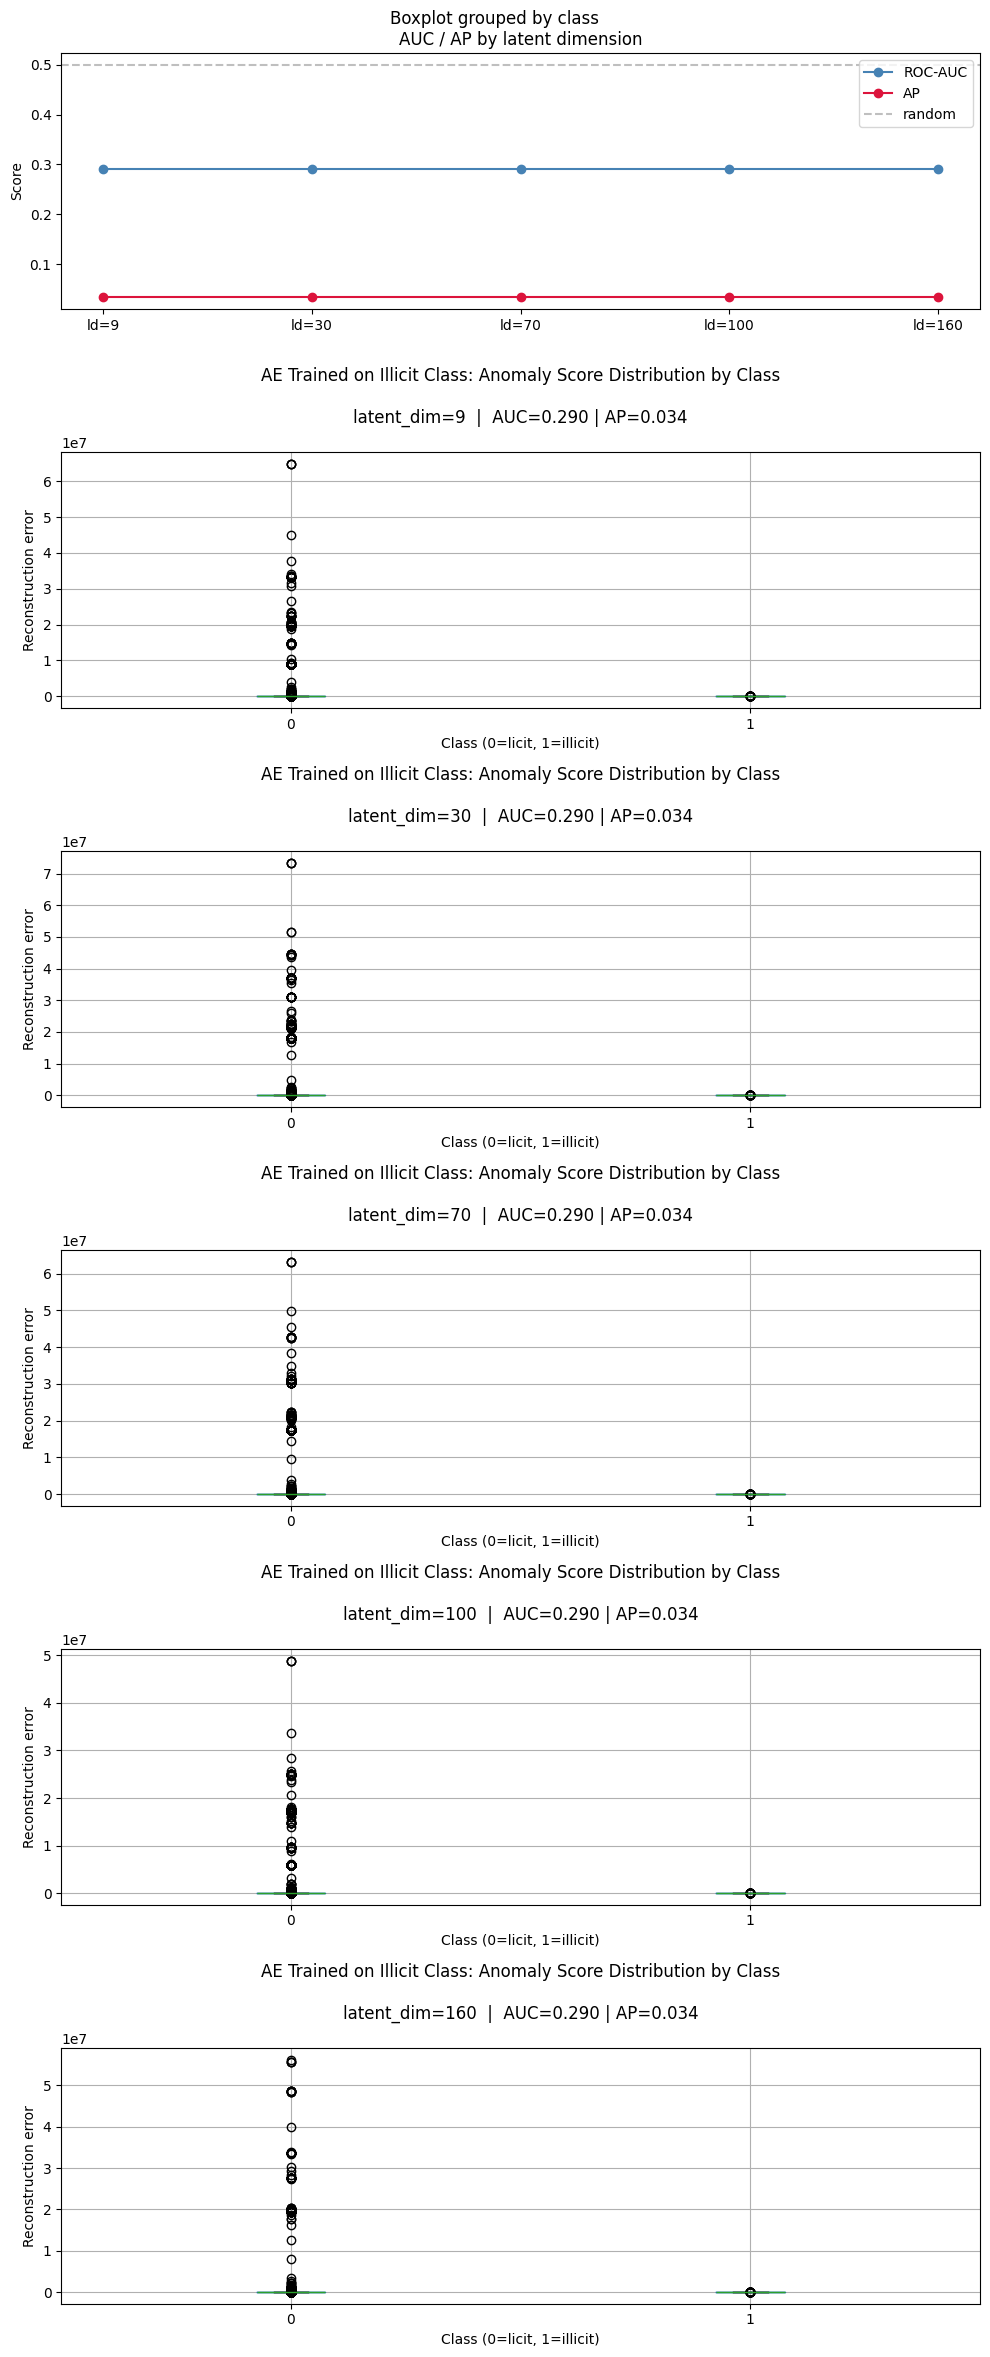

({9: {'test_results':             txId  time_step class  anomaly_score
   0       12781680         41     0   3.335713e+07
   1       39010634         41     2   2.530294e+00
   2       12688678         41     0   1.676018e+00
   3       12688662         41     2   5.271604e-01
   4       12803377         41     2   2.744561e-01
   ...          ...        ...   ...            ...
   42161  173077460         49     2   4.211209e-01
   42162  158577750         49     2   1.220117e+00
   42163  158375402         49     1   1.305581e+00
   42164  158654197         49     2   5.914605e-01
   42165  157597225         49     2   8.207931e-01
   
   [42166 rows x 4 columns],
   'losses': [0.9918452100225128,
    0.8721359809196086,
    0.7647221507146774,
    0.7287640828070866,
    0.7014512012085983,
    0.6675048659910355,
    0.635151822009542,
    0.6138252288790095,
    0.5892141791128039,
    0.5696748155204969,
    0.5494857310725357,
    0.5366591756220838,
    0.5178454956356702,
   

In [50]:
plot_ae_latent_comparison(ill_metrics_df, ld, ill_results, title_model="AE Trained on Illicit Class")